In [163]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import zscore


df = pd.read_csv("task2.csv", encoding="cp1252-")
df

,Unnamed: 0,ID,Name,Age,Photo,Nationality,Flag,Overall,Potential,Club,...,Composure,Marking,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,Release Clause
0,0,158023,L. Messi,31.0,https://cdn.sofifa.org/players/4/19/158023.png,Argentina,https://cdn.sofifa.org/flags/52.png,94.0,94,FC Barcelona,...,96.0,33.0,28.0,26.0,6.0,11.0,15.0,14.0,8.0,€226.5M
1,1,20801,Cristiano Ronaldo,33.0,https://cdn.sofifa.org/players/4/19/20801.png,Portugal,https://cdn.sofifa.org/flags/38.png,94.0,94,Juventus,...,95.0,28.0,31.0,23.0,7.0,11.0,15.0,14.0,11.0,€127.1M
2,2,190871,Neymar Jr,26.0,https://cdn.sofifa.org/players/4/19/190871.png,Brazil,https://cdn.sofifa.org/flags/54.png,92.0,93,Paris Saint-Germain,...,94.0,27.0,24.0,33.0,9.0,9.0,15.0,15.0,11.0,€228.1M
3,3,193080,De Gea,27.0,https://cdn.sofifa.org/players/4/19/193080.png,Spain,https://cdn.sofifa.org/flags/45.png,91.0,93,Manchester United,...,68.0,15.0,21.0,13.0,90.0,85.0,87.0,88.0,94.0,€138.6M
4,4,192985,K. De Bruyne,27.0,https://cdn.sofifa.org/players/4/19/192985.png,Belgium,https://cdn.sofifa.org/flags/7.png,91.0,92,Manchester City,...,88.0,68.0,58.0,51.0,15.0,13.0,5.0,10.0,13.0,€196.4M
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18202,18202,238813,J. Lundstram,19.0,https://cdn.sofifa.org/players/4/19/238813.png,England,https://cdn.sofifa.org/flags/14.png,47.0,65,Crewe Alexandra,...,45.0,40.0,48.0,47.0,10.0,13.0,7.0,8.0,9.0,€143K
18203,18203,243165,N. Christoffersson,19.0,https://cdn.sofifa.org/players/4/19/243165.png,Sweden,https://cdn.sofifa.org/flags/46.png,47.0,63,Trelleborgs FF,...,42.0,22.0,15.0,19.0,10.0,9.0,9.0,5.0,12.0,€113K
18204,18204,241638,B. Worman,16.0,https://cdn.sofifa.org/players/4/19/241638.png,England,https://cdn.sofifa.org/flags/14.png,47.0,67,Cambridge United,...,41.0,32.0,13.0,11.0,6.0,5.0,10.0,6.0,13.0,€165K
18205,18205,246268,D. Walker-Rice,17.0,https://cdn.sofifa.org/players/4/19/246268.png,England,https://cdn.sofifa.org/flags/14.png,47.0,66,Tranmere Rovers,...,46.0,20.0,25.0,27.0,14.0,6.0,14.0,8.0,9.0,€143K


In [164]:
players = df[["Finishing","ShortPassing","Dribbling","Interceptions","SprintSpeed","Strength","Stamina","StandingTackle","Value","Name"]]

players.dropna(inplace=True)

targets = players['Name']

players.drop(columns=["Name"], inplace=True)

def parse_value(value):
    if isinstance(value, (int, float)):
        return value

    if "M" in value:
        return float(value[1:-1]) * 1_000_000
    elif "K" in value:
        return float(value[1:-1]) * 1_000
    else:
        return float(value[1:])

players["Value"]=players["Value"].apply(parse_value)

C:\Users\User\AppData\Local\Temp\ipykernel_13636\933274684.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  players.dropna(inplace=True)
C:\Users\User\AppData\Local\Temp\ipykernel_13636\933274684.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  players.drop(columns=["Name"], inplace=True)
C:\Users\User\AppData\Local\Temp\ipykernel_13636\933274684.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returni

In [165]:
raw_data=players.copy()
raw_data["Name"] = targets
standardized_data = players.copy()
standardized_data.iloc[:, :] = zscore(standardized_data)
standardized_data["Name"] = targets.values

In [166]:
def cosine_similarity(data, target):
    dot = np.dot(data, target)
    data_norm = np.linalg.norm(data, axis=1)
    target_norm = np.linalg.norm(target)
    return dot / (data_norm * target_norm)

def manhattan_distance(data, target):
    return np.sum(np.abs(data - target), axis=1)

def euclidean_distance(data, target):
    return np.sqrt(np.sum((data - target) ** 2, axis=1))

In [167]:
def get_top_5(df, target_name, metric_func, is_similarity=False):

    target_row = df[df["Name"] == target_name]

    if target_row.empty:
        return "Target not found."

    data = df.drop(columns=["Name"]).values
    target_vec = target_row.drop(columns=["Name"]).values[0]

    scores = metric_func(data, target_vec)

    results = []
    names = df["Name"].values
    for i, score in enumerate(scores):
        if names[i] == target_name:
            continue

        results.append((i, names[i], score))

    results.sort(key=lambda x: x[2], reverse=is_similarity)

    return results[:5]

def print_results(title, results, is_similarity=False):
    print(f"\n{title}")
    print("-" * 45)
    print(f"{'Rank':<5}{'Player':<25}{'Score'}")
    print("-" * 45)

    for i, (_, name,score) in enumerate(results, 1):
        if is_similarity:
            print(f"{i:<5}{name:<25}{score*100:.2f}%")
        else:
            print(f"{i:<5}{name:<25}{score:.4f}")

In [168]:
print("\n========== RAW DATA ==========")
print_results(
    "Euclidean Distance",
    get_top_5(raw_data, "M. Salah", euclidean_distance)
)

print_results(
    "Manhattan Distance",
    get_top_5(raw_data, "M. Salah", manhattan_distance)
)

print_results(
    "Cosine Similarity",
    get_top_5(raw_data, "M. Salah", cosine_similarity, is_similarity=True),
    is_similarity=True
)



========== RAW DATA ==========

Euclidean Distance
---------------------------------------------
Rank Player                   Score
---------------------------------------------
1    Coutinho                 26.0768
2    J. Rodríguez             29.8998
3    J. Oblak                 1500000.0067
4    L. Modri?                2500000.0006
5    De Gea                   2500000.0032

Manhattan Distance
---------------------------------------------
Rank Player                   Score
---------------------------------------------
1    J. Rodríguez             60.0000
2    Coutinho                 66.0000
3    J. Oblak                 1500358.0000
4    L. Modri?                2500127.0000
5    De Gea                   2500307.0000

Cosine Similarity
---------------------------------------------
Rank Player                   Score
---------------------------------------------
1    Coutinho                 100.00%
2    J. Rodríguez             100.00%
3    L. Sané                  100.00%
4

In [169]:
m=get_top_5(standardized_data, "M. Salah", manhattan_distance)
e=get_top_5(standardized_data, "M. Salah", euclidean_distance)
c=get_top_5(standardized_data, "M. Salah", cosine_similarity, is_similarity=True)
print("\n========== STANDARDIZED DATA ==========")
print_results(
    "Euclidean Distance",e  
)

print_results(
    "Manhattan Distance",m
)

print_results(
    "Cosine Similarity",c,is_similarity=True
)


========== STANDARDIZED DATA ==========

Euclidean Distance
---------------------------------------------
Rank Player                   Score
---------------------------------------------
1    Coutinho                 1.6256
2    A. Griezmann             1.9636
3    J. Rodríguez             1.9733
4    L. Sané                  2.0156
5    Cristiano Ronaldo        2.0747

Manhattan Distance
---------------------------------------------
Rank Player                   Score
---------------------------------------------
1    J. Rodríguez             3.8170
2    A. Griezmann             3.8990
3    K. Mbappé                3.9292
4    Coutinho                 3.9985
5    L. Sané                  4.4138

Cosine Similarity
---------------------------------------------
Rank Player                   Score
---------------------------------------------
1    K. Mbappé                99.68%
2    Marco Asensio            99.53%
3    A. Griezmann             99.46%
4    E. Hazard                99.39

In [170]:
from collections import defaultdict

def combine_rankings(euclidean, manhattan, cosine):
    scores = {}

    for lst in [euclidean, manhattan, cosine]:
        for rank, (idx, name, _) in enumerate(lst, start=1):

            if name not in scores:
                scores[name] = [idx, name, 18]  

            scores[name][2] += rank - 6

    return sorted(scores.values(), key=lambda x: x[2])

In [171]:
final = combine_rankings(e, m, c)
print("\nFinal Ranking")
print("-" * 35)
print(f"{'Rank':<5}{'Player':<25}{'Total Score'}")

for i, (_,name, score) in enumerate(final, start=1):
    print(f"{i:<5}{name:<25}{score}")


Final Ranking
-----------------------------------
Rank Player                   Total Score
1    A. Griezmann             7
2    J. Rodríguez             10
3    K. Mbappé                10
4    Coutinho                 11
5    L. Sané                  14
6    Marco Asensio            14
7    E. Hazard                16
8    Cristiano Ronaldo        17


In [172]:
def pca_np(X,n):
  z=zscore(X)
  covariance_matrix = np.cov(z.T)
  eigenvalues, eigenvectors = np.linalg.eig(covariance_matrix)
  sorted_indices = np.argsort(eigenvalues)[::-1]
  eigenvalues = eigenvalues[sorted_indices]
  eigenvectors = eigenvectors[:, sorted_indices]
  projection_matrix = eigenvectors[:, :n]
  projection_data= np.dot(z,projection_matrix)
  return projection_data

In [173]:
projected = pca_np(players, 2)

top5 = get_top_5(
    standardized_data,
    "M. Salah",
    cosine_similarity,
    is_similarity=True
)


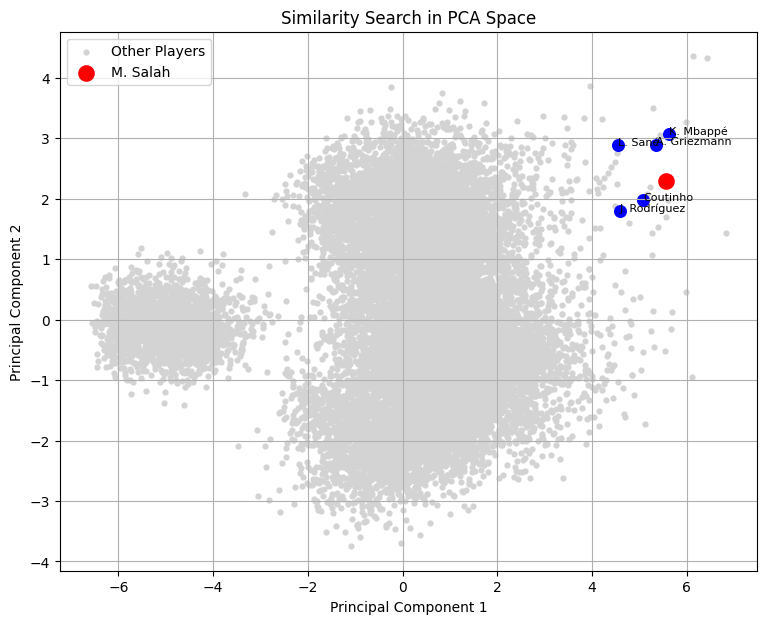

In [177]:
plt.figure(figsize=(9,7))


plot_df = pd.DataFrame(projected, columns=["PC1", "PC2"])
plot_df["Name"] = targets.values

plt.scatter(
    plot_df["PC1"],
    plot_df["PC2"],
    color="lightgray",
    s=12,
    label="Other Players"
)

target = plot_df[plot_df["Name"] == "M. Salah"]

plt.scatter(
    target["PC1"],
    target["PC2"],
    color="red",
    s=120,
    label="M. Salah"
)

for idx, name, _ in final[:5]:
    player = plot_df.loc[idx]

    plt.scatter(player["PC1"], player["PC2"], color="blue", s=70)
    plt.text(player["PC1"], player["PC2"], name, fontsize=8)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Similarity Search in PCA Space")
plt.legend()
plt.grid(True)
plt.show()